In [2]:
import numpy as np

# -----------------------------
# Hopfield / Little model (synchronous update) — Lab 3.1
# -----------------------------

def sign(x):
    """Lab convention: sign(x)=+1 if x>=0 else -1"""
    return np.where(x >= 0, 1, -1)

def hebbian_weights(patterns, scale_by_P=True, zero_diagonal=True):
    """
    Hebbian learning for bipolar patterns.
    patterns: (P, N) array with entries in {-1, +1}
    """
    P, N = patterns.shape
    W = np.zeros((N, N), dtype=float)
    for p in patterns:
        W += np.outer(p, p)
    if scale_by_P:
        W /= P
    if zero_diagonal:
        np.fill_diagonal(W, 0.0)
    return W

def little_update(x, W):
    """One synchronous (Little-model) update."""
    return sign(W @ x)

def run_until_fixed_or_cycle(x0, W, max_steps=200):
    """
    Runs synchronous updates until:
      - fixed point (x_{t+1} == x_t), OR
      - a cycle is detected (state repeats), OR
      - max_steps reached
    Returns:
      status: "fixed_point" | "cycle" | "max_steps"
      history: list of np arrays (includes x0 as t=0)
      cycle_states: list of tuples if cycle, else None
    """
    x = x0.copy()
    seen = {tuple(x.tolist()): 0}
    history = [x.copy()]

    for _t in range(1, max_steps + 1):
        x = little_update(x, W)
        key = tuple(x.tolist())
        history.append(x.copy())

        # fixed point
        if np.array_equal(history[-1], history[-2]):
            return "fixed_point", history, None

        # cycle
        if key in seen:
            start = seen[key]
            cycle_states = [tuple(s.tolist()) for s in history[start:-1]]
            return "cycle", history, cycle_states

        seen[key] = _t

    return "max_steps", history, None

def hamming(a, b):
    return int(np.sum(a != b))

def match_stored(x, stored):
    for name, vec in stored.items():
        if np.array_equal(x, vec):
            return name
    return None

def canonical_cycle(cycle_states):
    """
    cycle_states: list of tuples in order.
    Return canonical representation invariant to rotation & direction.
    """
    states = list(cycle_states)
    rev = list(reversed(states))

    def best_rotation(seq):
        rots = []
        L = len(seq)
        for r in range(L):
            rots.append(tuple(seq[r:] + seq[:r]))
        return min(rots)

    return min(best_rotation(states), best_rotation(rev))

def fmt_vec(x):
    return "[" + " ".join(f"{v:2d}" for v in x) + "]"

# -----------------------------
# Patterns from the lab handout
# -----------------------------
x1 = np.array([-1, -1,  1, -1,  1, -1, -1,  1])
x2 = np.array([-1, -1, -1, -1, -1,  1, -1, -1])
x3 = np.array([-1,  1,  1, -1, -1,  1, -1,  1])

stored = {"x1": x1, "x2": x2, "x3": x3}
patterns = np.vstack([x1, x2, x3])

# Distorted patterns (3.1)
x1d = np.array([ 1, -1,  1, -1,  1, -1, -1,  1])
x2d = np.array([ 1,  1, -1, -1, -1,  1, -1, -1])
x3d = np.array([ 1,  1,  1, -1,  1,  1, -1,  1])
distorted = {"x1d": x1d, "x2d": x2d, "x3d": x3d}

# -----------------------------
# Train weights
# -----------------------------
W = hebbian_weights(patterns, scale_by_P=True, zero_diagonal=True)

print("=== 3.1 A) Are x1,x2,x3 stable (fixed points)? ===")
for name, x in stored.items():
    x_next = little_update(x, W)
    print(f"{name}: fixed_point = {np.array_equal(x_next, x)}")

# -----------------------------
# 3.1 B) Distorted patterns: do they converge to stored patterns?
# -----------------------------
print("\n=== 3.1 B) Recall from distorted patterns (iterate until attractor) ===")
for name, x0 in distorted.items():
    status, history, cycle_states = run_until_fixed_or_cycle(x0, W, max_steps=200)
    xf = history[-1]
    m = match_stored(xf, stored)

    print(f"\nStart {name} = {fmt_vec(x0)}")
    print(f"  End status: {status}")
    print(f"  Steps taken: {len(history)-1}")

    if status == "fixed_point":
        print(f"  Fixed point: {fmt_vec(xf)}")
        print(f"  Matches stored: {m}")
    elif status == "cycle":
        cyc = canonical_cycle(cycle_states)
        print(f"  Reached a {len(cycle_states)}-cycle (Little-model oscillation).")
        print(f"  Cycle states: {cyc}")
        print("  (So it did NOT reach a single stable fixed point.)")
    else:
        print("  WARNING: max_steps reached without detecting fixed point/cycle.")

    # show closeness to stored patterns
    print(f"  Hamming to x1/x2/x3: {hamming(xf,x1)}/{hamming(xf,x2)}/{hamming(xf,x3)}")

# -----------------------------
# 3.1 C) Automated attractor search over all 2^8 states
#     CHANGE: store attractors + basins (which starts lead to which attractor)
# -----------------------------
print("\n=== 3.1 C) How many attractors are there? (search all 2^8 states) ===")
N = 8

all_states = []
for k in range(2**N):
    bits = [(k >> i) & 1 for i in range(N)][::-1]
    all_states.append(np.array([1 if b else -1 for b in bits], dtype=int))
all_states = np.array(all_states)

# Store:
# fixed_attractors: dict {fixed_point_tuple: [start_state_tuples...]}
# cycle_attractors: dict {canonical_cycle_tuple: [start_state_tuples...]}
fixed_attractors = {}
cycle_attractors = {}

for x0 in all_states:
    status, history, cycle_states = run_until_fixed_or_cycle(x0, W, max_steps=200)
    start_key = tuple(x0.tolist())

    if status == "fixed_point":
        fp = tuple(history[-1].tolist())
        fixed_attractors.setdefault(fp, []).append(start_key)

    elif status == "cycle":
        cyc = canonical_cycle(cycle_states)  # this is a tuple-of-tuples
        cycle_attractors.setdefault(cyc, []).append(start_key)

    else:
        # Shouldn't happen for this tiny system, but keep it explicit
        cycle_attractors.setdefault(("max_steps", tuple(history[-1].tolist())), []).append(start_key)

# Summary counts
stored_fixed = sum(
    1 for fp in fixed_attractors.keys()
    if match_stored(np.array(fp, dtype=int), stored) is not None
)

print(f"Fixed-point attractors: {len(fixed_attractors)}")
print(f"  of which stored (x1,x2,x3): {stored_fixed}")
print(f"Cycle attractors (Little-model): {len(cycle_attractors)}")
print(f"TOTAL attractors (fixed points + cycles): {len(fixed_attractors) + len(cycle_attractors)}")

# Print them nicely with basin sizes
print("\n--- Fixed-point attractors (with basin sizes) ---")
for i, (fp, starts) in enumerate(sorted(fixed_attractors.items(), key=lambda kv: (-len(kv[1]), kv[0])), start=1):
    fp_arr = np.array(fp, dtype=int)
    print(f"{i:2d}. basin_size={len(starts):3d}  fp={fp}  matches_stored={match_stored(fp_arr, stored)}")

print("\n--- Cycle attractors (with basin sizes) ---")
for i, (cyc, starts) in enumerate(sorted(cycle_attractors.items(), key=lambda kv: (-len(kv[1]), kv[0])), start=1):
    # cyc is canonical tuple-of-tuples describing the repeating states
    if isinstance(cyc, tuple) and len(cyc) > 0 and cyc[0] == "max_steps":
        print(f"{i:2d}. basin_size={len(starts):3d}  (max_steps bucket) last_state={cyc[1]}")
    else:
        print(f"{i:2d}. basin_size={len(starts):3d}  {len(cyc)}-cycle: {cyc}")

# Optional: if you want to see which start states map into a specific attractor,
# uncomment these examples:
# print("\nExample: starts that go to x1:")
# print(fixed_attractors.get(tuple(x1.tolist()), []))

# -----------------------------
# 3.1 D) More than half wrong: flip k bits of a stored pattern
# -----------------------------
print("\n=== 3.1 D) More than half wrong (flip > N/2 bits of x1) ===")
rng = np.random.default_rng(0)

k = 5  # > 8/2
flip_idx = rng.choice(N, size=k, replace=False)
x_bad = x1.copy()
x_bad[flip_idx] *= -1

status, history, cycle_states = run_until_fixed_or_cycle(x_bad, W, max_steps=200)
xf = history[-1]
m = match_stored(xf, stored)

print(f"Start = x1 with {k} flips at indices {flip_idx.tolist()}")
print(f"  Start state: {fmt_vec(x_bad)}")
print(f"  End status: {status}")
print(f"  Steps taken: {len(history)-1}")

if status == "fixed_point":
    print(f"  Fixed point: {fmt_vec(xf)}")
    print(f"  Matches stored: {m}")
elif status == "cycle":
    cyc = canonical_cycle(cycle_states)
    print(f"  Reached a {len(cycle_states)}-cycle.")
    print(f"  Cycle states: {cyc}")

print(f"  Hamming to x1/x2/x3: {hamming(xf,x1)}/{hamming(xf,x2)}/{hamming(xf,x3)}")


=== 3.1 A) Are x1,x2,x3 stable (fixed points)? ===
x1: fixed_point = True
x2: fixed_point = True
x3: fixed_point = True

=== 3.1 B) Recall from distorted patterns (iterate until attractor) ===

Start x1d = [ 1 -1  1 -1  1 -1 -1  1]
  End status: fixed_point
  Steps taken: 2
  Fixed point: [-1 -1  1 -1  1 -1 -1  1]
  Matches stored: x1
  Hamming to x1/x2/x3: 0/4/3

Start x2d = [ 1  1 -1 -1 -1  1 -1 -1]
  End status: cycle
  Steps taken: 2
  Reached a 2-cycle (Little-model oscillation).
  Cycle states: ((-1, -1, -1, 1, -1, 1, 1, -1), (1, 1, -1, -1, -1, 1, -1, -1))
  (So it did NOT reach a single stable fixed point.)
  Hamming to x1/x2/x3: 6/2/3

Start x3d = [ 1  1  1 -1  1  1 -1  1]
  End status: cycle
  Steps taken: 4
  Reached a 2-cycle (Little-model oscillation).
  Cycle states: ((-1, -1, 1, -1, -1, -1, -1, 1), (-1, -1, 1, -1, 1, 1, -1, 1))
  (So it did NOT reach a single stable fixed point.)
  Hamming to x1/x2/x3: 1/3/2

=== 3.1 C) How many attractors are there? (search all 2^8 state

Loaded pict.dat with shape (11, 1024) (patterns x 1024).


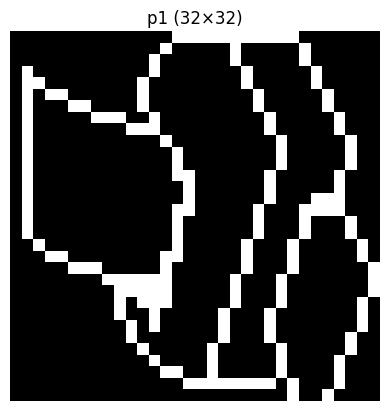

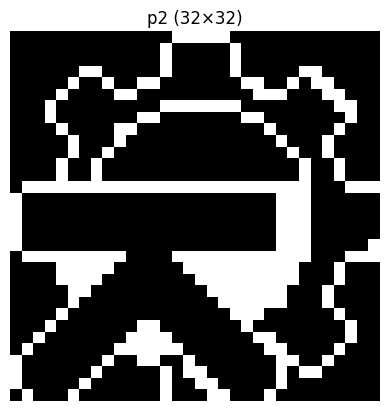

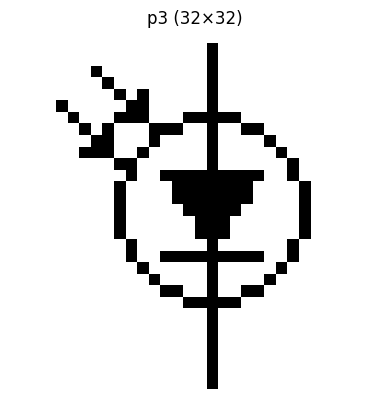


--- Stability check ---
p1: synchronous stable=True, asynchronous stable=True
p2: synchronous stable=True, asynchronous stable=True
p3: synchronous stable=True, asynchronous stable=True

--- Pattern completion tests ---
Using p10 from file.
Using p11 from file.


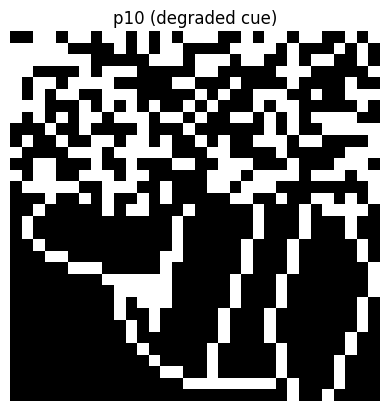

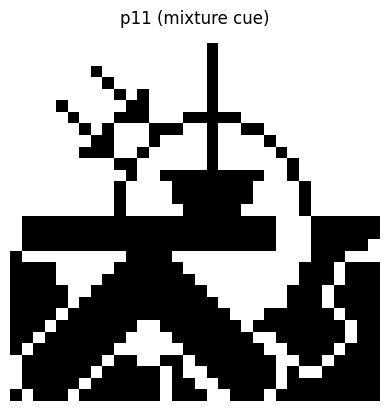


Synchronous recall from p10: converged=True, steps=2
  Matches p1/p2/p3: True/False/False
Synchronous recall from p11: converged=True, steps=3
  Matches p1/p2/p3: False/False/False


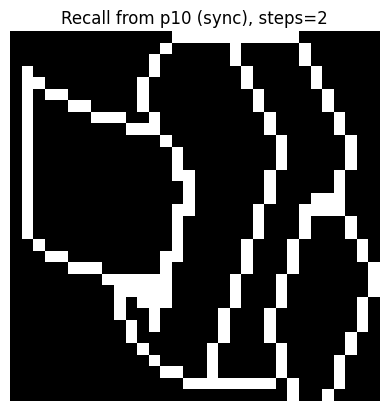

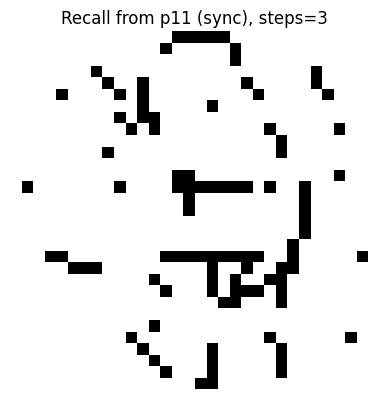

p10 converged: True steps: 2
p11 converged: True steps: 3
Matches p1/p2/p3: False False False

--- Sequential (random-unit) updates from p10 ---


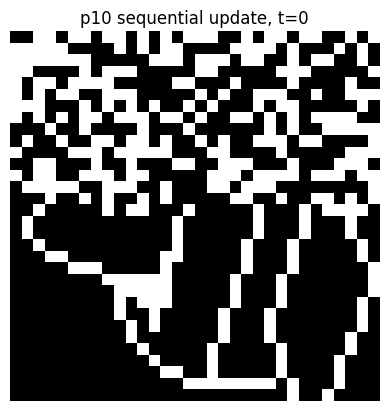

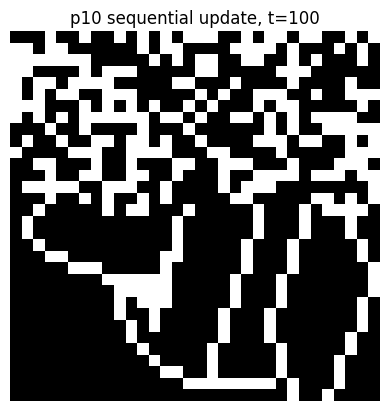

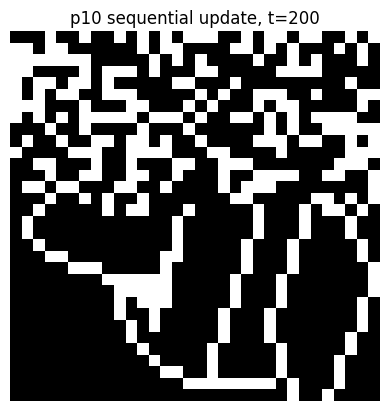

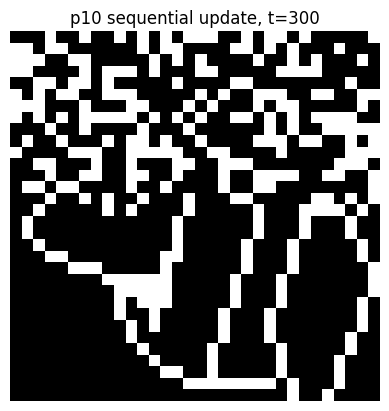

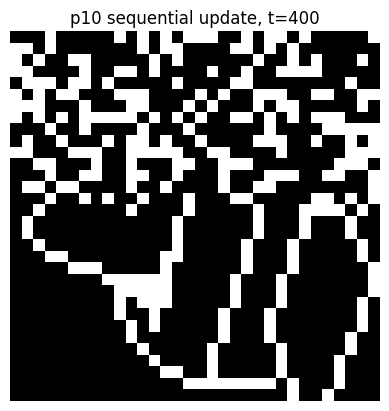

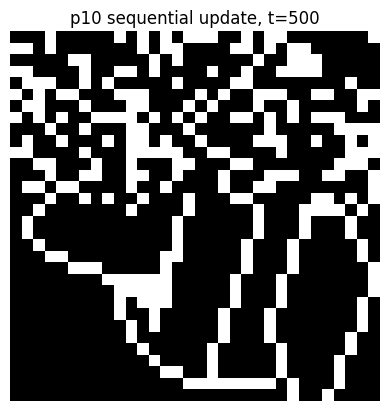

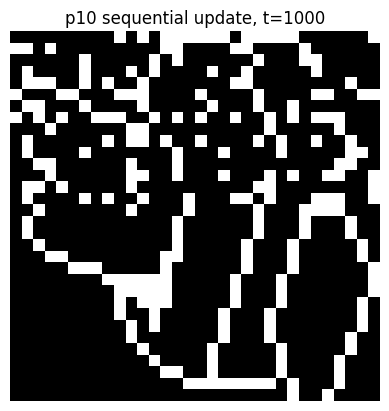

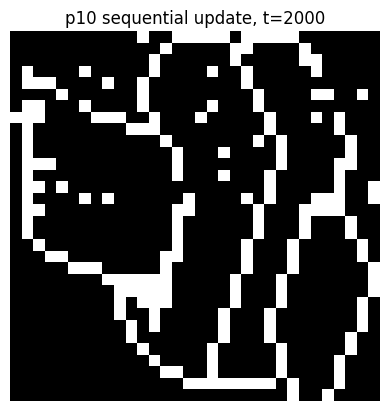

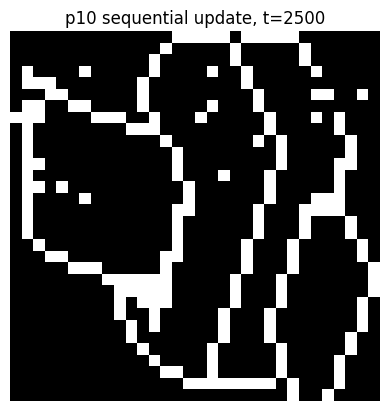

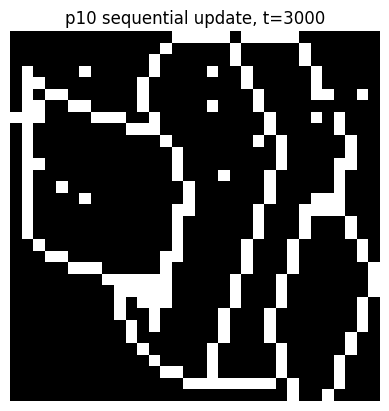

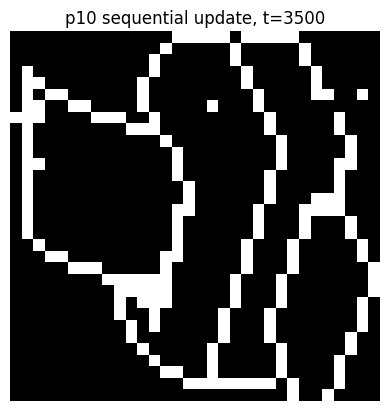

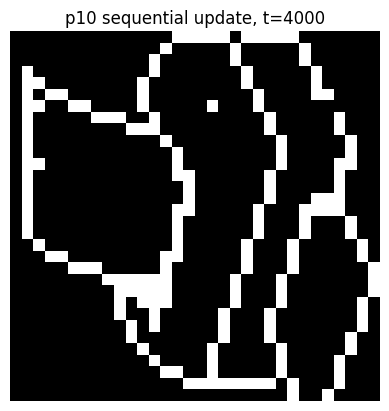

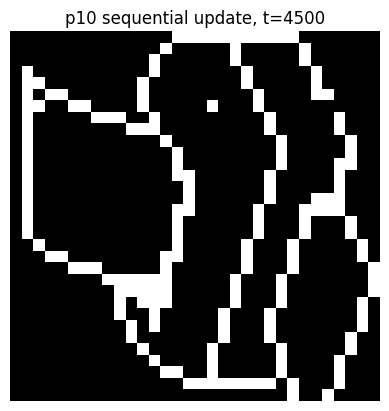

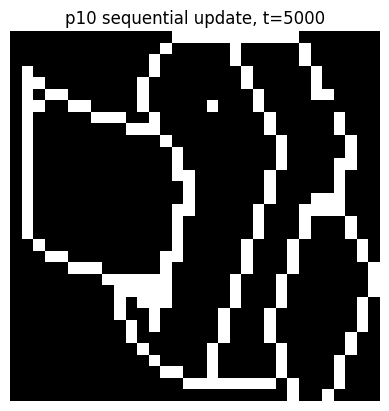

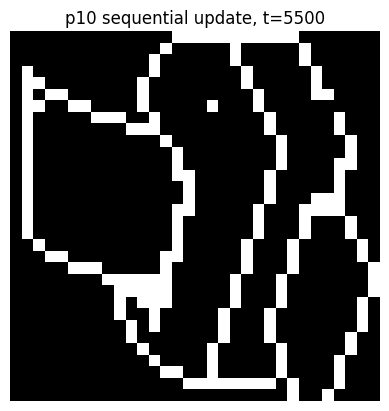

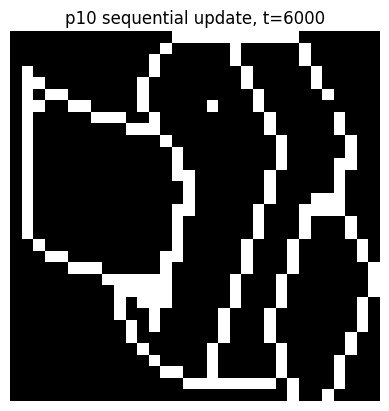

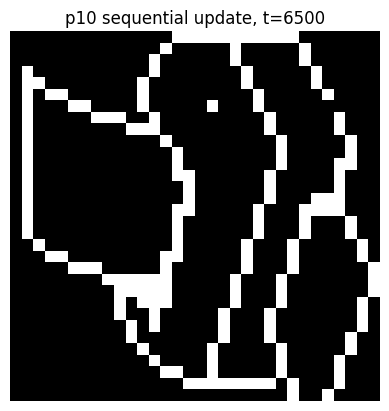

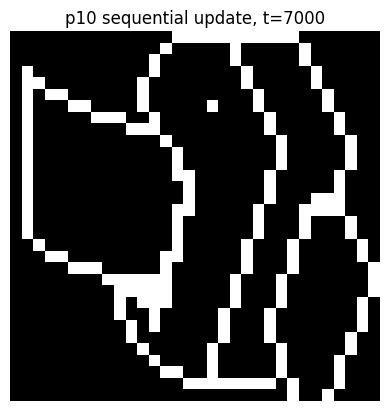

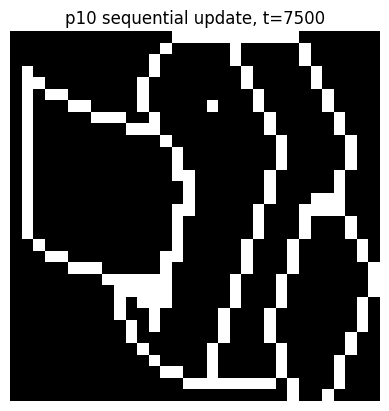

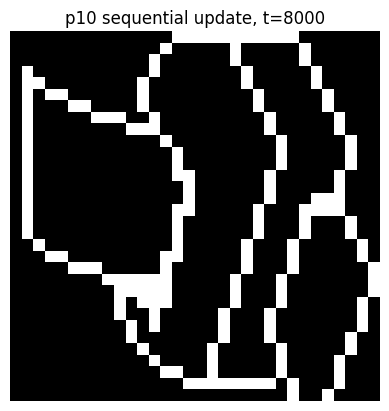


--- Sequential (random-unit) updates from p11 ---


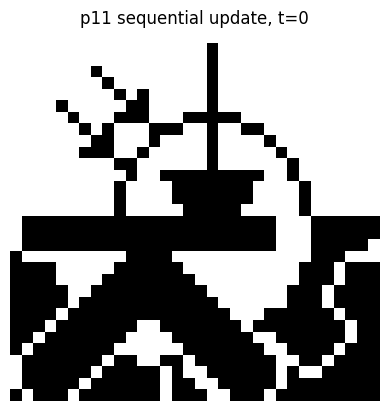

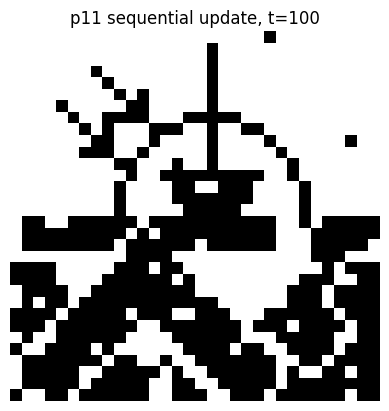

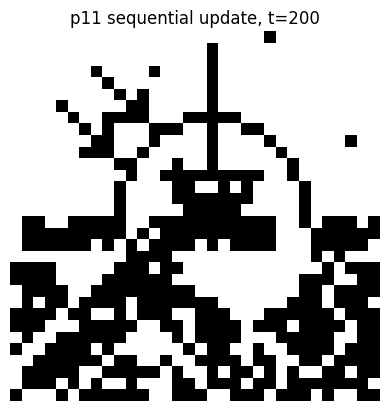

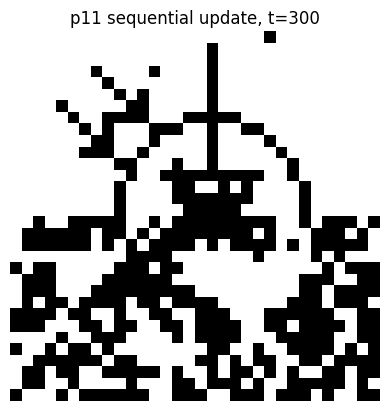

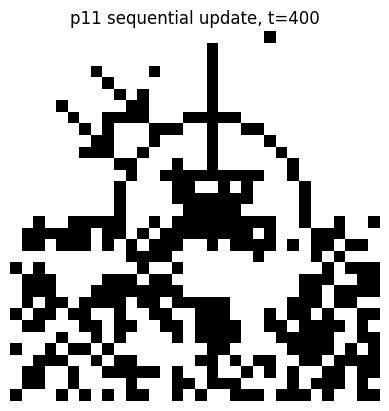

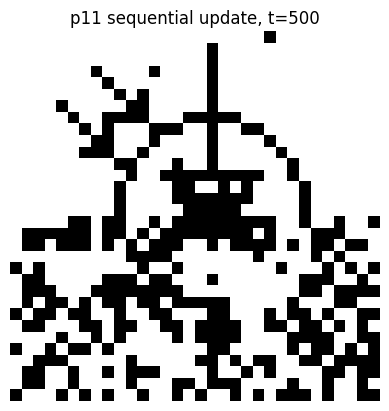

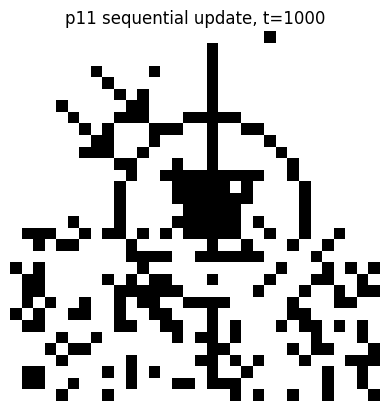

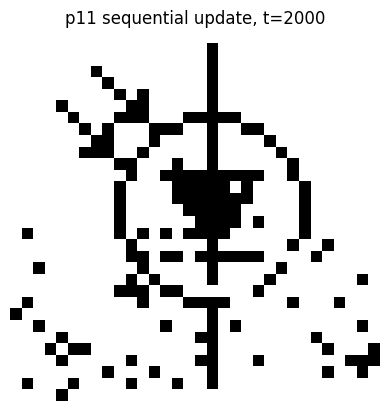

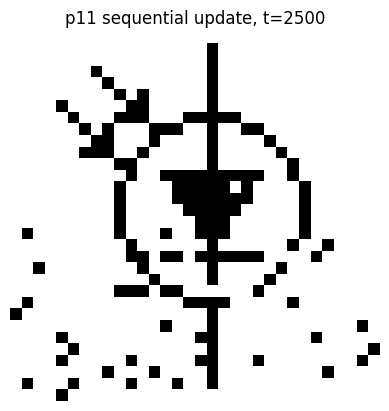

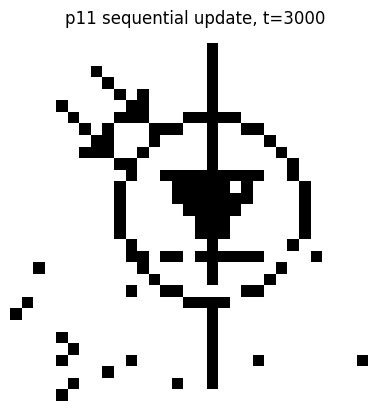

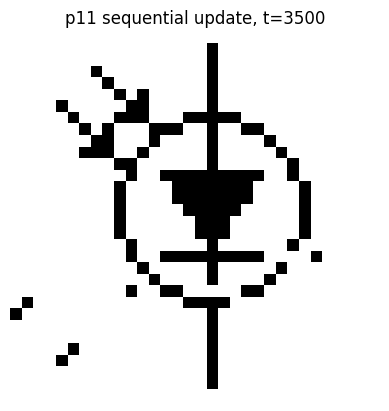

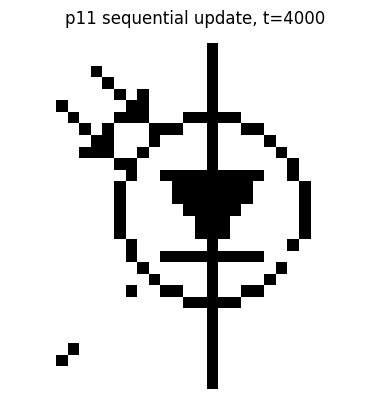

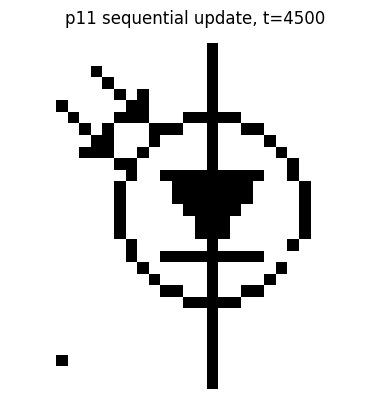

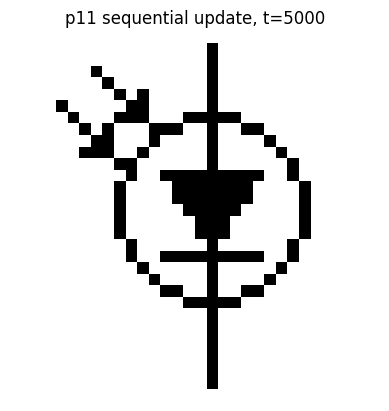

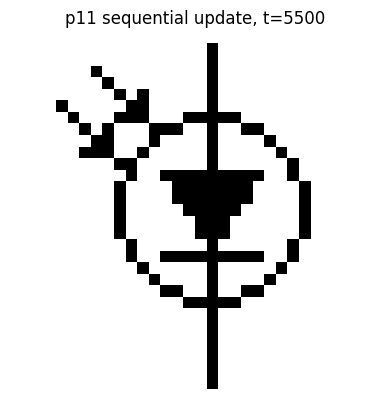

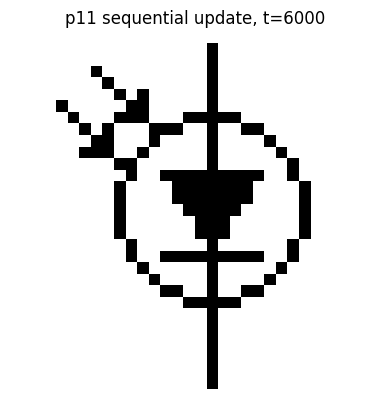

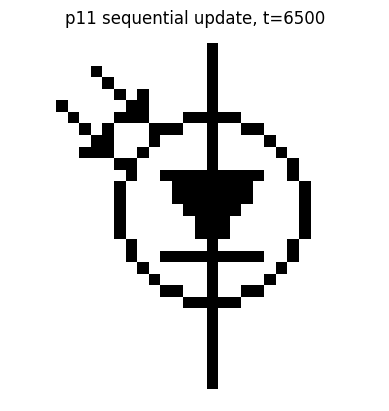

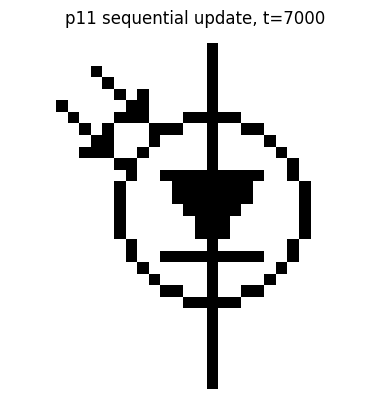

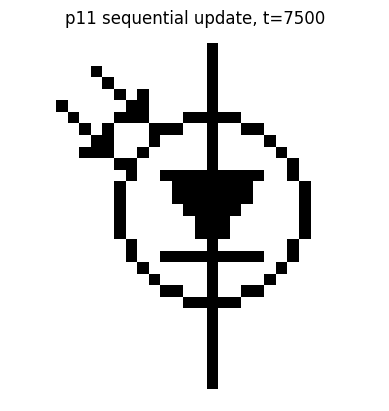

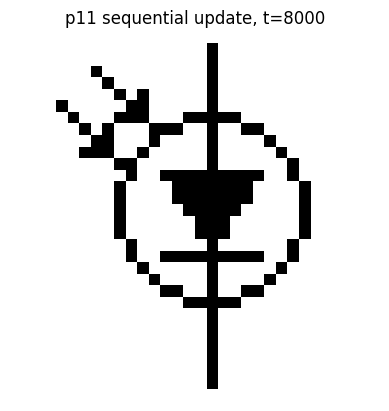

In [ ]:
import os
import matplotlib.pyplot as plt

# -----------------------------
# Lab 3.2: 1024-neuron Hopfield + sequential update
# -----------------------------

def sign(x):
    # lab convention
    return np.where(x >= 0, 1, -1)

def load_pict(path, N=1024):
    data = np.loadtxt(path, delimiter=",")

    if data.ndim == 1:
        if data.size % N != 0:
            raise ValueError(f"File has {data.size} numbers, not divisible by N={N}.")
        data = data.reshape((-1, N))
    else:
        if data.shape[1] != N and data.shape[0] == N:
            data = data.T
        if data.shape[1] != N:
            raise ValueError(f"Expected N={N} columns, got {data.shape[1]}.")

    return data.astype(int)


def show_pattern(p, title="", side=32):
    plt.figure()
    plt.imshow(p.reshape(side, side), cmap="gray", vmin=-1, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

def hebbian_weights(patterns, scale="1/N", zero_diagonal=True):
    """
    patterns: (P, N) bipolar {-1,+1}
    scale: "none" | "1/P" | "1/N"
    """
    P, N = patterns.shape
    W = np.zeros((N, N), dtype=float)
    for p in patterns:
        W += np.outer(p, p)

    if scale == "1/P":
        W /= P
    elif scale == "1/N":
        W /= N

    if zero_diagonal:
        np.fill_diagonal(W, 0.0)
    return W

def little_recall(x0, W, max_steps=20):
    """Synchronous (Little-model) recall until fixed point or max_steps."""
    x = x0.copy()
    for t in range(max_steps):
        x_new = sign(W @ x)
        if np.array_equal(x_new, x):
            return x_new, t + 1, True
        x = x_new
    return x, max_steps, False

def is_synchronous_stable(x, W):
    return np.array_equal(sign(W @ x), x)

def is_asynchronous_stable(x, W):
    """True if no single-neuron update would flip any bit (strong stability check)."""
    for i in range(x.size):
        h = W[i, :] @ x
        xi_new = 1 if h >= 0 else -1
        if xi_new != x[i]:
            return False
    return True

def async_random_updates(x0, W, n_updates=5000, snapshot_every=100, seed=0):
    """
    Sequential Hopfield dynamics:
      pick random unit i, update it, repeat.
    Returns final x and snapshots {t: state}.
    """
    rng = np.random.default_rng(seed)
    x = x0.copy()
    N = x.size
    snapshots = {0: x.copy()}

    for t in range(1, n_updates + 1):
        i = rng.integers(0, N)
        h = W[i, :] @ x
        x[i] = 1 if h >= 0 else -1

        if t % snapshot_every == 0:
            snapshots[t] = x.copy()

    return x, snapshots

def degrade_by_flips(p, frac=0.10, seed=0):
    """Flip frac of bits in a bipolar pattern."""
    rng = np.random.default_rng(seed)
    x = p.copy()
    k = int(round(frac * x.size))
    idx = rng.choice(x.size, size=k, replace=False)
    x[idx] *= -1
    return x

def mixture(p2, p3, frac_from_p3=0.5, seed=1):
    """Create a mixed cue: start from p2, replace frac with bits from p3."""
    rng = np.random.default_rng(seed)
    x = p2.copy()
    k = int(round(frac_from_p3 * x.size))
    idx = rng.choice(x.size, size=k, replace=False)
    x[idx] = p3[idx]
    return x

# -----------------------------
# CHANGE THIS PATH to where pict.dat is located
# -----------------------------
BASE_DIR = os.getcwd()
PATH = os.path.join(BASE_DIR, "pict.dat")
PATH = "pict.dat"   # e.g. "./data/pict.dat" or "/Users/you/Downloads/pict.dat"

if not os.path.exists( "pict.dat"):
    raise FileNotFoundError(
        f"pict.dat not found at: {PATH}\n"
        "Fix PATH to the correct location (or move pict.dat next to this script)."
    )

# -----------------------------
# Load patterns and pick p1..p3
# -----------------------------
P = load_pict(PATH, N=1024)
print(f"Loaded pict.dat with shape {P.shape} (patterns x 1024).")

p1, p2, p3 = P[0], P[1], P[2]

# Display p1..p3 as images
show_pattern(p1, "p1 (32×32)")
show_pattern(p2, "p2 (32×32)")
show_pattern(p3, "p3 (32×32)")

# -----------------------------
# Train Hopfield network on p1..p3
# -----------------------------
W = hebbian_weights(np.vstack([p1, p2, p3]), scale="1/N", zero_diagonal=True)

# -----------------------------
# (1) Check stability of p1..p3
# -----------------------------
print("\n--- Stability check ---")
for name, pat in [("p1", p1), ("p2", p2), ("p3", p3)]:
    sync_ok = is_synchronous_stable(pat, W)
    async_ok = is_asynchronous_stable(pat, W)
    print(f"{name}: synchronous stable={sync_ok}, asynchronous stable={async_ok}")

# -----------------------------
# (2) Pattern completion from p10 / p11
# -----------------------------
print("\n--- Pattern completion tests ---")
if P.shape[0] >= 10:
    p10 = P[9]
    print("Using p10 from file.")
else:
    p10 = degrade_by_flips(p1, frac=0.10, seed=0)
    print("p10 not found in file; generated degraded p1 by flipping 10% bits.")

if P.shape[0] >= 11:
    p11 = P[10]
    print("Using p11 from file.")
else:
    p11 = mixture(p2, p3, frac_from_p3=0.5, seed=1)
    print("p11 not found in file; generated mixture cue (50% bits from p3 into p2).")

show_pattern(p10, "p10 (degraded cue)")
show_pattern(p11, "p11 (mixture cue)")

rec10, steps10, conv10 = little_recall(p10, W, max_steps=100)
rec11, steps11, conv11 = little_recall(p11, W, max_steps=100)

print(f"\nSynchronous recall from p10: converged={conv10}, steps={steps10}")
print(f"  Matches p1/p2/p3: {np.array_equal(rec10,p1)}/{np.array_equal(rec10,p2)}/{np.array_equal(rec10,p3)}")

print(f"Synchronous recall from p11: converged={conv11}, steps={steps11}")
print(f"  Matches p1/p2/p3: {np.array_equal(rec11,p1)}/{np.array_equal(rec11,p2)}/{np.array_equal(rec11,p3)}")

show_pattern(rec10, f"Recall from p10 (sync), steps={steps10}")
show_pattern(rec11, f"Recall from p11 (sync), steps={steps11}")

print("p10 converged:", conv10, "steps:", steps10)
print("p11 converged:", conv11, "steps:", steps11)
print("Matches p1/p2/p3:",
      np.array_equal(rec11, p1),
      np.array_equal(rec11, p2),
      np.array_equal(rec11, p3))

# -----------------------------
# (3) Sequential (random-unit) Hopfield dynamics
#     Show image every 100 updates
# -----------------------------
print("\n--- Sequential (random-unit) updates from p10 ---")
final10, snaps10 = async_random_updates(p10, W, n_updates=8000, snapshot_every=100, seed=0)
for t in [0, 100, 200, 300, 400, 500, 1000, 2000, 2500,3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000]:
    show_pattern(snaps10[t], f"p10 sequential update, t={t}")

print("\n--- Sequential (random-unit) updates from p11 ---")
final11, snaps11 = async_random_updates(p11, W, n_updates=8000, snapshot_every=100, seed=0)
for t in [0, 100, 200, 300, 400, 500, 1000, 2000, 2500,3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000]:

    show_pattern(snaps11[t], f"p11 sequential update, t={t}")


In [ ]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir())


Current working directory: d:\KTH\Master\1st year\second semester\Artifical Neural Netwroks and Deep Architectures\labs\lab3
Files here: ['annda_lab3.pdf', 'lab3_answers.docx', 'lab3_notebook.ipynb', 'pict.dat', '~$b3_answers.docx']


Loaded pict.dat with shape (11, 1024) (patterns x 1024).
Using p10 from file.
Using p11 from file.

=== Q1) Energy at attractors (trained Hopfield W) ===
E(p1) = -1436.39
E(p2) = -1362.64
E(p3) = -1459.25
E(attractor from p10, async) = -1436.39
Matches p1/p2/p3: True/False/False
E(attractor from p11, async) = -1459.25
Matches p1/p2/p3: False/False/True

=== Q2) Energy at distorted patterns (initial cues) ===
E(p10 initial) = -412.98
E(p11 initial) = -170.5

=== Q3) Energy evolution during sequential updates (trained Hopfield W) ===
Monotone fraction for p10 trace: 1.0000 (should be ~1.0 for symmetric W)
Monotone fraction for p11 trace: 1.0000 (should be ~1.0 for symmetric W)


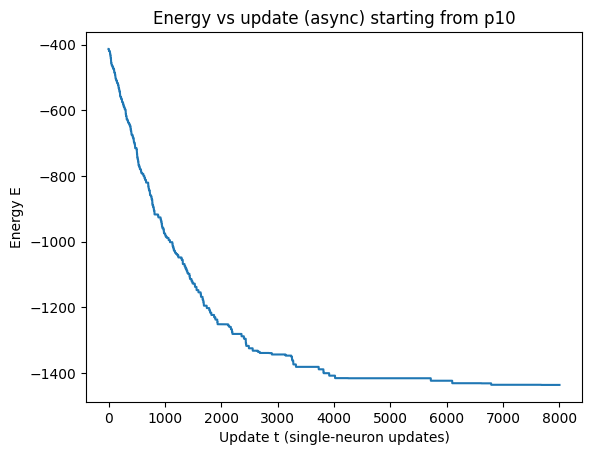

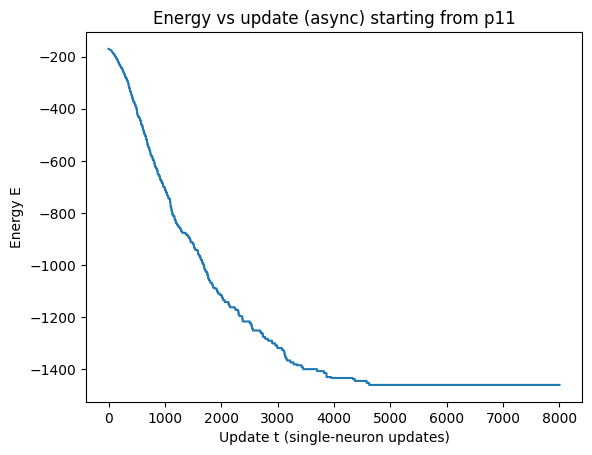


=== Q4) Random (asymmetric) weight matrix experiment ===
Monotone fraction (asymmetric random W): 0.8708 (typically < 1)
You should observe that energy is NOT guaranteed to decrease; it often fluctuates.


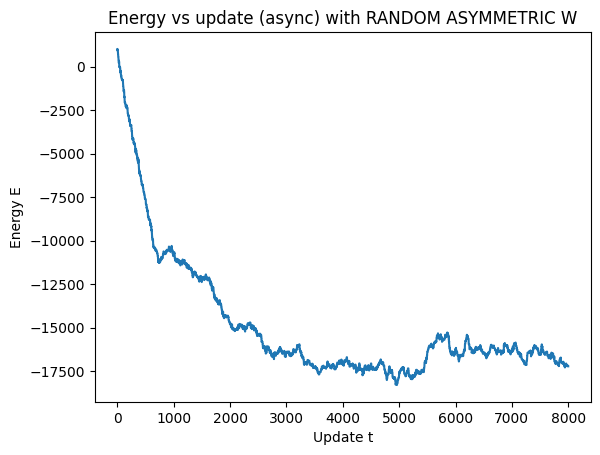


=== Q5) Symmetrized random weight matrix experiment ===
Monotone fraction (symmetrized random W): 1.0000 (should be ~1.0)
With symmetric W, the energy acts as a Lyapunov function under async updates, so it decreases and the network converges.


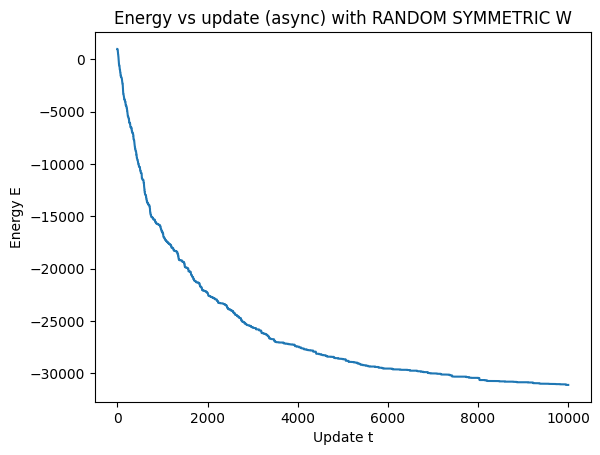


Stability check for final states (random W experiments):
Asymmetric random W final stable?: False
Symmetric random W final stable?: False


In [15]:
import numpy as np
import os
import matplotlib.pyplot as plt

# =============================
# Lab 3.3 Energy (asynchronous updates)
# Answers:
#  - Energy at attractors
#  - Energy at distorted patterns
#  - Energy vs iteration for sequential updates
#  - Random (asymmetric) W behavior
#  - Symmetrized W behavior + why
# =============================

# ---------- Helpers ----------
def sign(x):
    return np.where(x >= 0, 1, -1)

def load_pict(path, N=1024):
    # pict.dat in your case is comma-separated
    data = np.loadtxt(path, delimiter=",")
    if data.ndim == 1:
        if data.size % N != 0:
            raise ValueError(f"File has {data.size} numbers, not divisible by N={N}.")
        data = data.reshape((-1, N))
    else:
        if data.shape[1] != N and data.shape[0] == N:
            data = data.T
        if data.shape[1] != N:
            raise ValueError(f"Expected N={N} columns, got {data.shape[1]}.")
    # ensure ints
    return data.astype(int)

def show_pattern(p, title="", side=32):
    plt.figure()
    plt.imshow(p.reshape(side, side), cmap="gray", vmin=-1, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()

def hebbian_weights(patterns, scale="1/N", zero_diagonal=True):
    """
    patterns: (P, N) bipolar {-1,+1}
    scale: "none" | "1/P" | "1/N"
    """
    P, N = patterns.shape
    W = np.zeros((N, N), dtype=float)
    for p in patterns:
        W += np.outer(p, p)

    if scale == "1/P":
        W /= P
    elif scale == "1/N":
        W /= N

    if zero_diagonal:
        np.fill_diagonal(W, 0.0)
    return W

def energy(x, W):
    """
    Lab uses: E = - sum_i sum_j w_ij x_i x_j
    Matrix form: E = - x^T W x
    """
    return float(-(x @ (W @ x)))

def little_recall_sync(x0, W, max_steps=30):
    """
    Synchronous recall (not used for the convergence proof, but handy to find an attractor quickly).
    """
    x = x0.copy()
    for t in range(max_steps):
        x_new = sign(W @ x)
        if np.array_equal(x_new, x):
            return x_new, t + 1, True
        x = x_new
    return x, max_steps, False

def async_random_updates_with_energy(x0, W, n_updates=8000, snapshot_every=100, seed=0, keep_tie=False):
    """
    Sequential Hopfield dynamics:
      pick random unit i
      compute its field h_i = sum_j w_ij x_j
      update x_i = sign(h_i)

    Returns:
      x_final
      energies: list of energy after each update
      snapshots: dict {t: state}, including t=0
    """
    rng = np.random.default_rng(seed)
    x = x0.copy()
    N = x.size

    energies = [energy(x, W)]
    snapshots = {0: x.copy()}

    for t in range(1, n_updates + 1):
        i = rng.integers(0, N)
        h = W[i, :] @ x

        if keep_tie:
            if h > 0:
                x[i] = 1
            elif h < 0:
                x[i] = -1
            # else: keep x[i]
        else:
            x[i] = 1 if h >= 0 else -1

        energies.append(energy(x, W))

        if t % snapshot_every == 0:
            snapshots[t] = x.copy()

    return x, np.array(energies), snapshots

def degrade_by_flips(p, frac=0.10, seed=0):
    rng = np.random.default_rng(seed)
    x = p.copy()
    k = int(round(frac * x.size))
    idx = rng.choice(x.size, size=k, replace=False)
    x[idx] *= -1
    return x

def mixture(p2, p3, frac_from_p3=0.5, seed=1):
    rng = np.random.default_rng(seed)
    x = p2.copy()
    k = int(round(frac_from_p3 * x.size))
    idx = rng.choice(x.size, size=k, replace=False)
    x[idx] = p3[idx]
    return x

def energy_monotone_fraction(energies):
    # fraction of steps where E(t+1) <= E(t)
    diffs = np.diff(energies)
    return float(np.mean(diffs <= 1e-12))

# ---------- Load data ----------
PATH = "pict.dat"
if not os.path.exists(PATH):
    raise FileNotFoundError(f"Could not find {PATH}. Put pict.dat next to this script/notebook.")

P = load_pict(PATH, N=1024)
print(f"Loaded pict.dat with shape {P.shape} (patterns x 1024).")

p1, p2, p3 = P[0], P[1], P[2]

# If p10/p11 exist in file use them; otherwise generate
if P.shape[0] >= 10:
    p10 = P[9]
    print("Using p10 from file.")
else:
    p10 = degrade_by_flips(p1, frac=0.10, seed=0)
    print("p10 not found; generated degraded p1 (10% flips).")

if P.shape[0] >= 11:
    p11 = P[10]
    print("Using p11 from file.")
else:
    p11 = mixture(p2, p3, frac_from_p3=0.5, seed=1)
    print("p11 not found; generated mixture cue (50/50).")

# ---------- Train Hopfield weights on p1..p3 ----------
W_hop = hebbian_weights(np.vstack([p1, p2, p3]), scale="1/N", zero_diagonal=True)

# =============================
# Q1) Energy at different attractors
# We'll take:
#  - stored patterns p1,p2,p3 (known attractors)
#  - the sequential final states reached from p10 and p11 (attractors reached by dynamics)
# =============================
print("\n=== Q1) Energy at attractors (trained Hopfield W) ===")
E_p1 = energy(p1, W_hop)
E_p2 = energy(p2, W_hop)
E_p3 = energy(p3, W_hop)
print(f"E(p1) = {E_p1:.6g}")
print(f"E(p2) = {E_p2:.6g}")
print(f"E(p3) = {E_p3:.6g}")

# Find attractors reached from cues using sequential updates
final10, E_trace10, _ = async_random_updates_with_energy(p10, W_hop, n_updates=8000, snapshot_every=100, seed=0, keep_tie=False)
final11, E_trace11, _ = async_random_updates_with_energy(p11, W_hop, n_updates=8000, snapshot_every=100, seed=0, keep_tie=False)

print(f"E(attractor from p10, async) = {energy(final10, W_hop):.6g}")
print(f"Matches p1/p2/p3: {np.array_equal(final10,p1)}/{np.array_equal(final10,p2)}/{np.array_equal(final10,p3)}")

print(f"E(attractor from p11, async) = {energy(final11, W_hop):.6g}")
print(f"Matches p1/p2/p3: {np.array_equal(final11,p1)}/{np.array_equal(final11,p2)}/{np.array_equal(final11,p3)}")

# =============================
# Q2) Energy at distorted points (p10, p11)
# =============================
print("\n=== Q2) Energy at distorted patterns (initial cues) ===")
print(f"E(p10 initial) = {energy(p10, W_hop):.6g}")
print(f"E(p11 initial) = {energy(p11, W_hop):.6g}")

# =============================
# Q3) Track energy iteration-by-iteration during sequential update
# =============================
print("\n=== Q3) Energy evolution during sequential updates (trained Hopfield W) ===")
print(f"Monotone fraction for p10 trace: {energy_monotone_fraction(E_trace10):.4f} (should be ~1.0 for symmetric W)")
print(f"Monotone fraction for p11 trace: {energy_monotone_fraction(E_trace11):.4f} (should be ~1.0 for symmetric W)")

plt.figure()
plt.plot(E_trace10)
plt.title("Energy vs update (async) starting from p10")
plt.xlabel("Update t (single-neuron updates)")
plt.ylabel("Energy E")
plt.show()

plt.figure()
plt.plot(E_trace11)
plt.title("Energy vs update (async) starting from p11")
plt.xlabel("Update t (single-neuron updates)")
plt.ylabel("Energy E")
plt.show()

# =============================
# Q4) Random normally distributed weights (asymmetric) + iterate
# =============================
print("\n=== Q4) Random (asymmetric) weight matrix experiment ===")
rng = np.random.default_rng(123)
N = 1024

W_rand = rng.normal(0, 1, size=(N, N))
np.fill_diagonal(W_rand, 0.0)

# arbitrary starting state
x0 = rng.choice([-1, 1], size=N)

x_rand_final, E_rand_trace, _ = async_random_updates_with_energy(x0, W_rand, n_updates=8000, snapshot_every=500, seed=1, keep_tie=False)
mono_rand = energy_monotone_fraction(E_rand_trace)

print(f"Monotone fraction (asymmetric random W): {mono_rand:.4f} (typically < 1)")
print("You should observe that energy is NOT guaranteed to decrease; it often fluctuates.")

plt.figure()
plt.plot(E_rand_trace)
plt.title("Energy vs update (async) with RANDOM ASYMMETRIC W")
plt.xlabel("Update t")
plt.ylabel("Energy E")
plt.show()

# =============================
# Q5) Symmetrize the random matrix and repeat
# =============================
print("\n=== Q5) Symmetrized random weight matrix experiment ===")
W_sym = 0.5 * (W_rand + W_rand.T)
np.fill_diagonal(W_sym, 0.0)

x_sym_final, E_sym_trace, _ = async_random_updates_with_energy(x0, W_sym, n_updates=10000, snapshot_every=500, seed=1, keep_tie=False)
mono_sym = energy_monotone_fraction(E_sym_trace)

print(f"Monotone fraction (symmetrized random W): {mono_sym:.4f} (should be ~1.0)")
print("With symmetric W, the energy acts as a Lyapunov function under async updates, so it decreases and the network converges.")

plt.figure()
plt.plot(E_sym_trace)
plt.title("Energy vs update (async) with RANDOM SYMMETRIC W")
plt.xlabel("Update t")
plt.ylabel("Energy E")
plt.show()

# Optional: show that it converges to a fixed point (no single-bit update changes it)
def is_asynchronous_stable(x, W):
    for i in range(x.size):
        h = W[i, :] @ x
        xi_new = 1 if h >= 0 else -1
        if xi_new != x[i]:
            return False
    return True

print("\nStability check for final states (random W experiments):")
print("Asymmetric random W final stable?:", is_asynchronous_stable(x_rand_final, W_rand))
print("Symmetric random W final stable?:", is_asynchronous_stable(x_sym_final, W_sym))


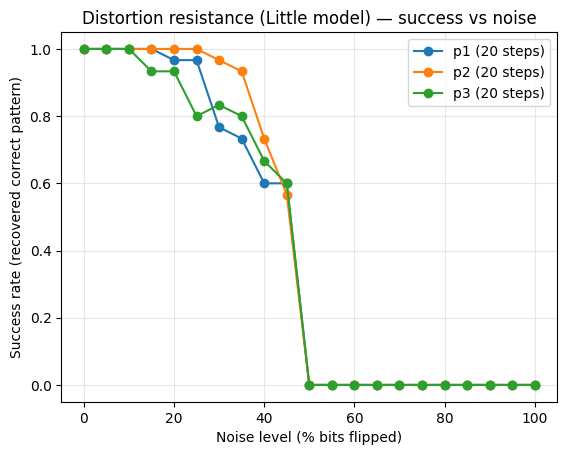

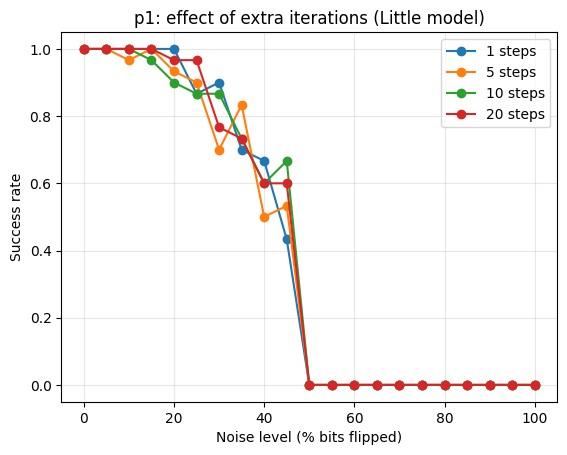

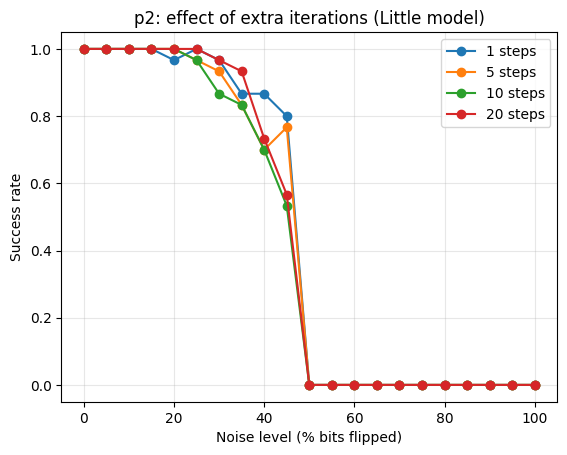

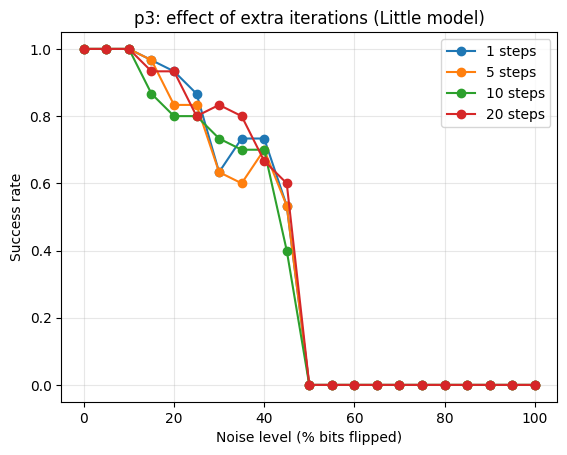

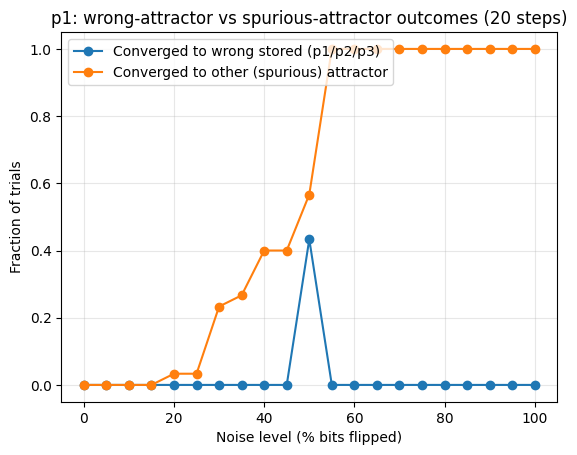

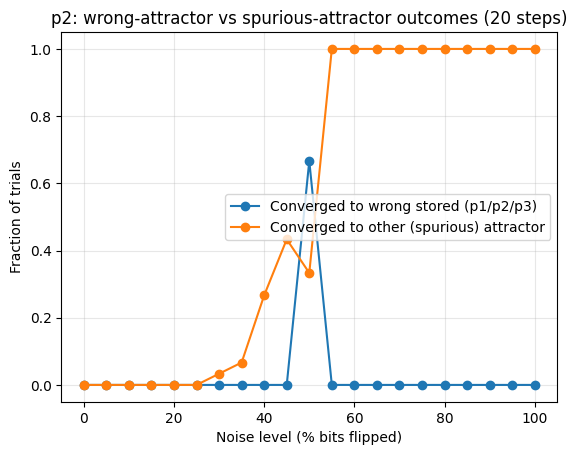

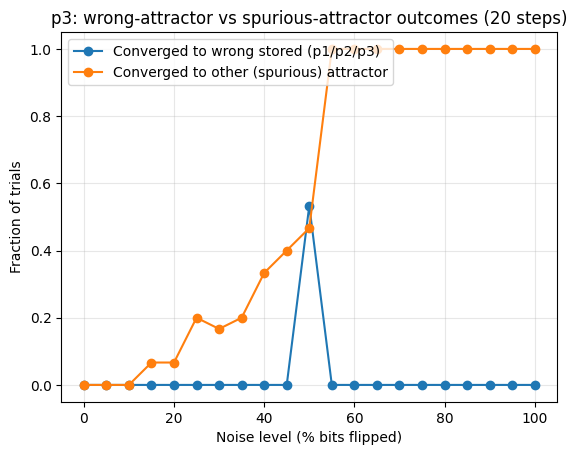


================= 3.4 Summary (based on simulations) =================
Trials per noise level: 30
Noise grid: 21 points from 0% to 100%
Interpretation: success = recovered correct pattern; wrong = converged to another stored; other = spurious attractor.

Noise tolerance (max noise with >= 50% success), using 20 steps:
  p1: up to ~45.0% noise
  p2: up to ~45.0% noise
  p3: up to ~45.0% noise

Do extra iterations help? (compare 1 step vs 20 steps at moderate noise levels)
  p1 at ~10% noise: success 1-step=1.00, 20-steps=1.00
  p1 at ~20% noise: success 1-step=1.00, 20-steps=0.97
  p1 at ~30% noise: success 1-step=0.90, 20-steps=0.77
  p1 at ~40% noise: success 1-step=0.67, 20-steps=0.60

  p2 at ~10% noise: success 1-step=1.00, 20-steps=1.00
  p2 at ~20% noise: success 1-step=0.97, 20-steps=1.00
  p2 at ~30% noise: success 1-step=0.97, 20-steps=0.97
  p2 at ~40% noise: success 1-step=0.87, 20-steps=0.73

  p3 at ~10% noise: success 1-step=1.00, 20-steps=1.00
  p3 at ~20% noise: succes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Lab 3.4 Distortion Resistance (Little model / synchronous)
# -----------------------------

def sign(x):
    return np.where(x >= 0, 1, -1)

def load_pict(path, N=1024):
    # Your pict.dat is comma-separated
    data = np.loadtxt(path, delimiter=",")
    if data.ndim == 1:
        if data.size % N != 0:
            raise ValueError(f"File has {data.size} numbers, not divisible by N={N}.")
        data = data.reshape((-1, N))
    else:
        if data.shape[1] != N and data.shape[0] == N:
            data = data.T
        if data.shape[1] != N:
            raise ValueError(f"Expected N={N} columns, got {data.shape[1]}.")
    return data.astype(int)

def hebbian_weights(patterns, scale="1/N", zero_diagonal=True):
    P, N = patterns.shape
    W = np.zeros((N, N), dtype=float)
    for p in patterns:
        W += np.outer(p, p)
    if scale == "1/P":
        W /= P
    elif scale == "1/N":
        W /= N
    if zero_diagonal:
        np.fill_diagonal(W, 0.0)
    return W

def little_step(x, W):
    return sign(W @ x)

def little_run(x0, W, max_steps=10):
    """
    Run synchronous updates up to max_steps.
    Stops early if fixed point is reached.
    Returns final state and steps_used.
    """
    x = x0.copy()
    for t in range(1, max_steps + 1):
        x_new = little_step(x, W)
        if np.array_equal(x_new, x):
            return x_new, t
        x = x_new
    return x, max_steps

def add_noise_by_flips(x, frac, rng):
    """
    Flip frac of bits in bipolar pattern x in {-1,+1}.
    frac in [0,1].
    """
    x_noisy = x.copy()
    N = x_noisy.size
    k = int(round(frac * N))
    if k > 0:
        idx = rng.choice(N, size=k, replace=False)
        x_noisy[idx] *= -1
    return x_noisy

def which_stored(x, stored_dict):
    for name, pat in stored_dict.items():
        if np.array_equal(x, pat):
            return name
    return None

def simulate_noise_curve(
    W,
    stored_dict,
    target_name,
    noise_levels,
    trials=30,
    steps_list=(1, 5, 10, 20),
    seed=0
):
    """
    For one target pattern (e.g. p1), run trials across noise levels and
    compute, for each max_steps in steps_list:

      - success_rate: converges to the correct target pattern
      - wrong_stored_rate: converges to another stored pattern (p2/p3)
      - other_rate: converges to something else (spurious attractor etc.)

    Returns dict: results[max_steps] = dict of arrays keyed by 'success','wrong','other'
    """
    rng = np.random.default_rng(seed)
    target = stored_dict[target_name]
    results = {}

    for max_steps in steps_list:
        succ = np.zeros(len(noise_levels), dtype=float)
        wrong = np.zeros(len(noise_levels), dtype=float)
        other = np.zeros(len(noise_levels), dtype=float)

        for i, frac in enumerate(noise_levels):
            succ_count = wrong_count = other_count = 0

            for _ in range(trials):
                x0 = add_noise_by_flips(target, frac, rng)
                xf, _ = little_run(x0, W, max_steps=max_steps)

                hit = which_stored(xf, stored_dict)
                if hit == target_name:
                    succ_count += 1
                elif hit is not None and hit != target_name:
                    wrong_count += 1
                else:
                    other_count += 1

            succ[i] = succ_count / trials
            wrong[i] = wrong_count / trials
            other[i] = other_count / trials

        results[max_steps] = {"success": succ, "wrong": wrong, "other": other}

    return results

# -----------------------------
# Load data + train on p1,p2,p3
# -----------------------------
PATH = "pict.dat"
if not os.path.exists(PATH):
    raise FileNotFoundError(f"Could not find {PATH}. Put pict.dat next to this notebook/script.")

P = load_pict(PATH, N=1024)
p1, p2, p3 = P[0], P[1], P[2]
stored = {"p1": p1, "p2": p2, "p3": p3}

W = hebbian_weights(np.vstack([p1, p2, p3]), scale="1/N", zero_diagonal=True)

# -----------------------------
# Experiment settings
# -----------------------------
noise_levels = np.linspace(0.0, 1.0, 21)   # 0%, 5%, ..., 100%
trials = 30                                 # increase for smoother curves (e.g., 50-100)
steps_list = (1, 5, 10, 20)                 # test "extra iterations help?"
seed = 0

# -----------------------------
# Run simulations for p1, p2, p3
# -----------------------------
all_results = {}
for name in ["p1", "p2", "p3"]:
    all_results[name] = simulate_noise_curve(
        W, stored, target_name=name,
        noise_levels=noise_levels, trials=trials,
        steps_list=steps_list, seed=seed + (1 if name=="p2" else 2 if name=="p3" else 0)
    )

# -----------------------------
# Plot success rates (answers: noise tolerance + differences between attractors)
# -----------------------------
plt.figure()
for pat in ["p1", "p2", "p3"]:
    # pick a representative iteration budget (e.g. 20 steps) for the main "how much noise removed?" plot
    succ = all_results[pat][20]["success"]
    plt.plot(noise_levels * 100, succ, marker="o", label=f"{pat} (20 steps)")

plt.xlabel("Noise level (% bits flipped)")
plt.ylabel("Success rate (recovered correct pattern)")
plt.title("Distortion resistance (Little model) — success vs noise")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# Plot effect of extra iterations for EACH pattern (answers: do extra iterations help?)
# -----------------------------
for pat in ["p1", "p2", "p3"]:
    plt.figure()
    for max_steps in steps_list:
        plt.plot(noise_levels * 100, all_results[pat][max_steps]["success"], marker="o", label=f"{max_steps} steps")
    plt.xlabel("Noise level (% bits flipped)")
    plt.ylabel("Success rate")
    plt.title(f"{pat}: effect of extra iterations (Little model)")
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# -----------------------------
# Plot wrong-attractor and other-attractor rates (answers: does it always converge right? any other attractors?)
# -----------------------------
for pat in ["p1", "p2", "p3"]:
    plt.figure()
    wrong = all_results[pat][20]["wrong"]
    other = all_results[pat][20]["other"]
    plt.plot(noise_levels * 100, wrong, marker="o", label="Converged to wrong stored (p1/p2/p3)")
    plt.plot(noise_levels * 100, other, marker="o", label="Converged to other (spurious) attractor")
    plt.xlabel("Noise level (% bits flipped)")
    plt.ylabel("Fraction of trials")
    plt.title(f"{pat}: wrong-attractor vs spurious-attractor outcomes (20 steps)")
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# -----------------------------
# Print a compact numeric summary that directly answers the questions
# -----------------------------
def max_noise_for_threshold(success_curve, noise_levels, threshold=0.5):
    """
    Return the largest noise fraction where success >= threshold.
    If it never reaches threshold, return None.
    """
    ok = np.where(success_curve >= threshold)[0]
    if len(ok) == 0:
        return None
    return noise_levels[ok[-1]]

print("\n================= 3.4 Summary (based on simulations) =================")
print(f"Trials per noise level: {trials}")
print(f"Noise grid: {len(noise_levels)} points from 0% to 100%")
print("Interpretation: success = recovered correct pattern; wrong = converged to another stored; other = spurious attractor.\n")

# "How much noise can be removed?" -> report e.g. 50% success threshold at 20 steps
threshold = 0.5
print(f"Noise tolerance (max noise with >= {int(threshold*100)}% success), using 20 steps:")
for pat in ["p1", "p2", "p3"]:
    succ20 = all_results[pat][20]["success"]
    nmax = max_noise_for_threshold(succ20, noise_levels, threshold=threshold)
    if nmax is None:
        print(f"  {pat}: never reaches {int(threshold*100)}% success")
    else:
        print(f"  {pat}: up to ~{nmax*100:.1f}% noise")

print("\nDo extra iterations help? (compare 1 step vs 20 steps at moderate noise levels)")
for pat in ["p1", "p2", "p3"]:
    # pick a few mid noise indices for quick comparison
    for pct in [10, 20, 30, 40]:
        # find closest grid point
        idx = int(np.argmin(np.abs(noise_levels*100 - pct)))
        s1 = all_results[pat][1]["success"][idx]
        s20 = all_results[pat][20]["success"][idx]
        print(f"  {pat} at ~{noise_levels[idx]*100:.0f}% noise: success 1-step={s1:.2f}, 20-steps={s20:.2f}")
    print()

print("Do we always converge to the right attractor? (20 steps)")
for pat in ["p1", "p2", "p3"]:
    wrong20 = all_results[pat][20]["wrong"]
    other20 = all_results[pat][20]["other"]
    # show at a few noise points
    for pct in [20, 40, 60, 80]:
        idx = int(np.argmin(np.abs(noise_levels*100 - pct)))
        print(f"  {pat} at ~{noise_levels[idx]*100:.0f}% noise: wrong_stored={wrong20[idx]:.2f}, spurious_other={other20[idx]:.2f}")
    print()

print("======================================================================\n")
